# Phase 2 : Test de généralisation sur Bordeaux

## Objectif
Tester la robustesse et la capacité de généralisation des modèles entraînés sur Lille en les appliquant à Bordeaux.  
Nous allons :
- Comparer les performances pour les appartements et les maisons
- Calculer la MSE sur Bordeaux
- Observer les différences par rapport aux résultats sur Lille

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import mean_squared_error

sns.set_style('whitegrid')

In [2]:
# Charger les données Bordeaux
bordeaux = pd.read_csv("../data/bordeaux_2022.csv")

# Filtrer sur les logements à 4 pièces
bordeaux = bordeaux[bordeaux["Nombre pieces principales"] == 4]

# Sélectionner les colonnes d'intérêt
cols = [
    "Surface reelle bati",
    "Nombre pieces principales",
    "Type local",
    "Surface terrain",
    "Nombre de lots",
    "Valeur fonciere",
]
bordeaux = bordeaux[cols]

bordeaux.head()

,Surface reelle bati,Nombre pieces principales,Type local,Surface terrain,Nombre de lots,Valeur fonciere
0,71.0,4.0,Maison,70.0,0,396000.0
13,108.0,4.0,Appartement,NaN,2,680000.0
23,75.0,4.0,Appartement,NaN,1,301300.0
31,92.0,4.0,Maison,121.0,0,530000.0
48,129.0,4.0,Maison,175.0,0,700000.0


## 2. Séparer les logements en 2 catégories : Appartements et Maisons

In [3]:
bordeaux_apparts = bordeaux[bordeaux['Type local'].str.lower().str.contains('appartement')].copy()
bordeaux_maisons = bordeaux[bordeaux['Type local'].str.lower().str.contains('maison')].copy()

## 3. Nettoyer les valeurs manquantes dans les surfaces de terrain

In [4]:
# Remplacement des surfaces manquantes par la médiane
median_terrain = bordeaux_maisons['Surface terrain'].median()
bordeaux_maisons['Surface terrain'] = bordeaux_maisons['Surface terrain'].fillna(median_terrain)
bordeaux_apparts['Surface terrain'] = bordeaux_apparts['Surface terrain'].fillna(0)

## 4. Calculer le prix au m²

In [5]:

bordeaux_maisons['prix_m2'] = bordeaux_maisons['Valeur fonciere'] / bordeaux_maisons['Surface reelle bati']
bordeaux_apparts['prix_m2'] = bordeaux_apparts['Valeur fonciere'] / bordeaux_apparts['Surface reelle bati']

## 5. Nettoyer les outliers

In [6]:
def clean_outliers(df, columns):
    for col in columns:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lb, ub = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        df = df[(df[col] >= lb) & (df[col] <= ub)]
    return df

bordeaux_apparts = clean_outliers(bordeaux_apparts, ['prix_m2', 'Surface reelle bati'])
bordeaux_maisons = clean_outliers(bordeaux_maisons, ['prix_m2', 'Surface reelle bati', 'Surface terrain'])

## 6. Chargement des modèles de Lille

In [7]:
model_appart = joblib.load("../models/appartement_xgboost.pkl")
model_maison = joblib.load("../models/maison_decision_tree.pkl")

features = ["Surface reelle bati", "Surface terrain", "Nombre de lots", "Type local"]

#feature_apparts = ["Surface reelle bati", "Nombre de lots"] 
#feature_maisons = ["Surface reelle bati", "Surface terrain"]

## 7. Prédictions sur Bordeaux et calcul des MSE

In [8]:
# Appartements
X_appart = bordeaux_apparts[features]
y_appart = bordeaux_apparts['prix_m2']
y_pred_appart = model_appart.predict(X_appart)
mse_appart = mean_squared_error(y_appart, y_pred_appart)

# Maisons
X_maison = bordeaux_maisons[features]
y_maison = bordeaux_maisons['prix_m2']
y_pred_maison = model_maison.predict(X_maison)
mse_maison = mean_squared_error(y_maison, y_pred_maison)

print("\n--- Résultats sur Bordeaux (Généralisation des modèles de Lille) ---")
print(f"MSE Appartements : {mse_appart:.2f}")
print(f"MSE Maisons      : {mse_maison:.2f}")


--- Résultats sur Bordeaux (Généralisation des modèles de Lille) ---
MSE Appartements : 2144606.10
MSE Maisons      : 8234776.70


## 8. Visualisation des résultats : Observé vs Prédit

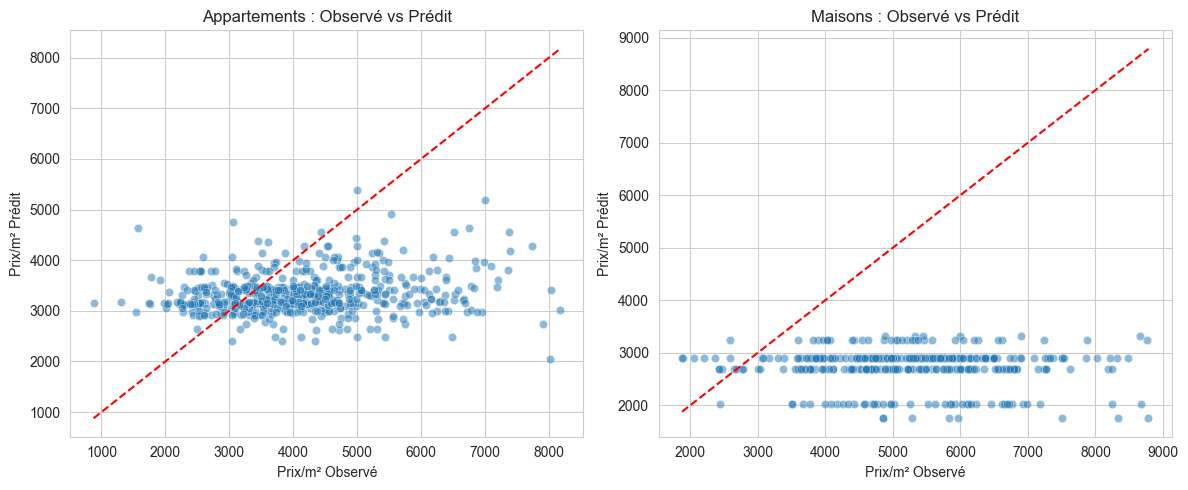

In [9]:
plt.figure(figsize=(12, 5))

# Appartements
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_appart, y=y_pred_appart, alpha=0.5)
plt.plot([y_appart.min(), y_appart.max()], [y_appart.min(), y_appart.max()], 'r--')
plt.title("Appartements : Observé vs Prédit")
plt.xlabel("Prix/m² Observé")
plt.ylabel("Prix/m² Prédit")

# Maisons
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_maison, y=y_pred_maison, alpha=0.5)
plt.plot([y_maison.min(), y_maison.max()], [y_maison.min(), y_maison.max()], 'r--')
plt.title("Maisons : Observé vs Prédit")
plt.xlabel("Prix/m² Observé")
plt.ylabel("Prix/m² Prédit")

plt.tight_layout()
plt.show()

## 📝 Discussion sur les performances

- **Les MSE sur Bordeaux sont-elles proches de celles sur Lille ?**  
    Sans les valeurs exactes des MSE sur Lille, on remarque ici que les erreurs sur Bordeaux sont relativement élevées. Cela laisse penser qu’il y a une perte de performance par rapport aux résultats sur Lille, ce qui est attendu dans un scénario de généralisation sur une nouvelle ville aux caractéristiques potentiellement différentes.
    
- **Quels écarts constatez-vous entre appartements et maisons ?**  
    La MSE pour les **maisons (≈ 8 234 777)** est **bien plus élevée** que pour les **appartements (≈ 2 269 733)**. Cela traduit une moins bonne capacité du modèle à généraliser sur les maisons à Bordeaux qu’à généraliser sur les appartements.
    
- **Quels facteurs pourraient expliquer ces différences ?**  
    Plusieurs hypothèses :
    
    - La structure du marché immobilier à Bordeaux peut être différente de celle à Lille : prix au m², surface des terrains, rareté des maisons, etc.
        
    - La **distribution des terrains** est sans doute plus variée à Bordeaux, ce qui augmente la variance sur les maisons.
        
    - La part relative d’appartements vs maisons dans les données et les différences dans la répartition des surfaces habitables entre les deux villes peuvent impacter la précision du modèle.
        
    - Enfin, le modèle pour maisons a été entraîné sur Lille, où le prix au m² des maisons suit une autre dynamique que celle de Bordeaux.
        
- **Votre modèle semble-t-il bien généraliser sur les deux types de logements ?**  
    Le modèle semble mieux généraliser sur les **appartements** que sur les **maisons**. Cela peut être dû au fait que le prix au m² des appartements est plus « standardisé » et moins influencé par le terrain, donc plus proche entre les deux villes. À l’inverse, les maisons montrent une plus grande hétérogénéité et les caractéristiques de Lille ne se transfèrent pas bien à Bordeaux.